In [1]:
#!pip install alpha_vantage
#!pip install lightgbm 
#!pip install numpy_financial 
##!pip install xgboost

In [2]:
# 📦 Importing libraries for modeling, preprocessing, and evaluation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy_financial 
from alpha_vantage.timeseries import TimeSeries
from sklearn.pipeline import make_pipeline
import matplotlib.ticker as mtick
from sklearn.linear_model import LinearRegression

In [3]:
# Load cleaned SEO dataset from previous notebook
file_path = r'df_exported.parquet'
modelling_seo = pd.read_parquet(file_path)

# Drop an unused categorical column
modelling_seo = modelling_seo.drop(columns=['Industry_Classification_Code'])


In [4]:
# Display unique values in the 'cat17' column
unique_values = modelling_seo['cat17'].dropna().unique()

# Flatten all combinations (some rows have multiple industries separated by ;)
all_groups = modelling_seo['cat17'].dropna().str.split(';').sum()
unique_groups = set([x.strip() for x in all_groups])  # Clean whitespace

# One-hot encode 'cat17' column
modelling_seo = pd.get_dummies(modelling_seo, columns=['cat17'], prefix='Cat17', drop_first=True, dtype='int8')


In [5]:
# Replace infinite values in log volume
modelling_seo['log_trading_vol'].replace([np.inf, -np.inf], 0, inplace=True)

# Drop columns with more than 20% missing
missing_percent = modelling_seo.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.2].index.tolist()
modelling_seo = modelling_seo.drop(columns=cols_to_drop)

# Drop rows with any missing values
modelling_seo = modelling_seo.dropna()


C:\Users\Analog iT\AppData\Local\Temp\ipykernel_17988\2232839197.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  modelling_seo['log_trading_vol'].replace([np.inf, -np.inf], 0, inplace=True)


In [6]:
# Sort dataset by Issue Date to respect time dependency
df_sorted = modelling_seo.sort_values('Issue_Date').reset_index(drop=True)

# Separate target and features
X_full = df_sorted.drop(columns=['UnderPricing_PCT'])
X_dates = X_full[['Offer_Date', 'Issue_Date']]  # Keep for simulation later
X_model = X_full.drop(columns=['Offer_Date', 'Issue_Date'])  # Modeling only
X_model.columns = X_model.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
y = df_sorted['UnderPricing_PCT']

# Fit LassoCV with scaling
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
lasso.fit(X_model, y)

# Keep only selected features with non-zero coefficients
coef = lasso.named_steps['lassocv'].coef_
selected_features = X_model.columns[coef != 0]
X_model = X_model[selected_features]


d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.002048082889668734, tolerance: 0.0010442670665479512
  model = cd_fast.enet_coordinate_descent_gram(
d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.002611903840239904, tolerance: 0.0010442670665479512
  model = cd_fast.enet_coordinate_descent_gram(
d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003155568050924984, tolerance: 0.0010442670665479512
  model = cd_fast.enet_coordinate_descent_gram(
d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did

In [7]:
# Define scaled and unscaled model dictionaries
scaled_models = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'KNN': KNeighborsRegressor()
}

unscaled_models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42, force_col_wise=True)
}

# Merge all models for evaluation loop
all_models = {**scaled_models, **unscaled_models}


In [8]:
param_grids = {
    'Ridge': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Lasso': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]},
    'KNN': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    'Decision Tree': {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1], 'subsample': [0.8, 1.0]},
    'LightGBM': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1], 'num_leaves': [31, 50]}
}


In [9]:
tscv = TimeSeriesSplit(n_splits=5)
X_scaled = StandardScaler().fit_transform(X_model)
results_summary = {}

for name, model in all_models.items():
    is_scaled = name in scaled_models
    fold_rmse_scores, fold_r2_scores = [], []

    for train_idx, test_idx in tscv.split(X_model):
        # Apply scaling conditionally
        if is_scaled:
            X_train = pd.DataFrame(X_scaled[train_idx], columns=X_model.columns)
            X_test = pd.DataFrame(X_scaled[test_idx], columns=X_model.columns)
        else:
            X_train = X_model.iloc[train_idx]
            X_test = X_model.iloc[test_idx]

        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        grid = GridSearchCV(estimator=model, param_grid=param_grids.get(name, {}), 
                            scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
        grid.fit(X_train, y_train)
        y_pred = grid.best_estimator_.predict(X_test)

        fold_rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        fold_r2_scores.append(r2_score(y_test, y_pred))

    results_summary[name] = {
        "avg_rmse": np.mean(fold_rmse_scores),
        "avg_r2": np.mean(fold_r2_scores),
        "best_params": grid.best_params_
    }


[LightGBM] [Info] Total Bins 1718
[LightGBM] [Info] Number of data points in the train set: 743, number of used features: 33
[LightGBM] [Info] Start training from score 0.028600
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [10]:
results_summary

{'Ridge': {'avg_rmse': 0.05324457530428177,
  'avg_r2': -0.012292404989095184,
  'best_params': {'alpha': 100}},
 'Lasso': {'avg_rmse': 0.05311587670907099,
  'avg_r2': -0.006886115423470618,
  'best_params': {'alpha': 0.0001}},
 'KNN': {'avg_rmse': 0.054280966921743334,
  'avg_r2': -0.05104818356855052,
  'best_params': {'n_neighbors': 9, 'weights': 'uniform'}},
 'Decision Tree': {'avg_rmse': 0.05410476279181155,
  'avg_r2': -0.04520809114711828,
  'best_params': {'max_depth': 3, 'min_samples_split': 2}},
 'Random Forest': {'avg_rmse': 0.05265946939966324,
  'avg_r2': 0.010327432770905153,
  'best_params': {'max_depth': 5,
   'min_samples_split': 2,
   'n_estimators': 100}},
 'Gradient Boosting': {'avg_rmse': 0.05301144631485598,
  'avg_r2': -0.0031953213600828256,
  'best_params': {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}},
 'XGBoost': {'avg_rmse': 0.052811674946069344,
  'avg_r2': 0.004520820890635435,
  'best_params': {'learning_rate': 0.01,
   'max_depth': 3,
  

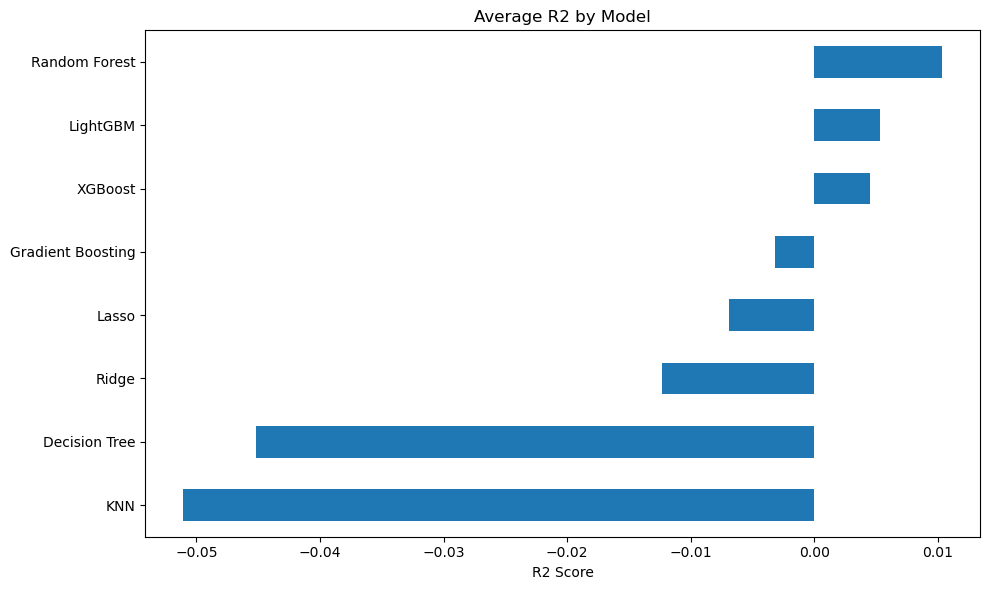

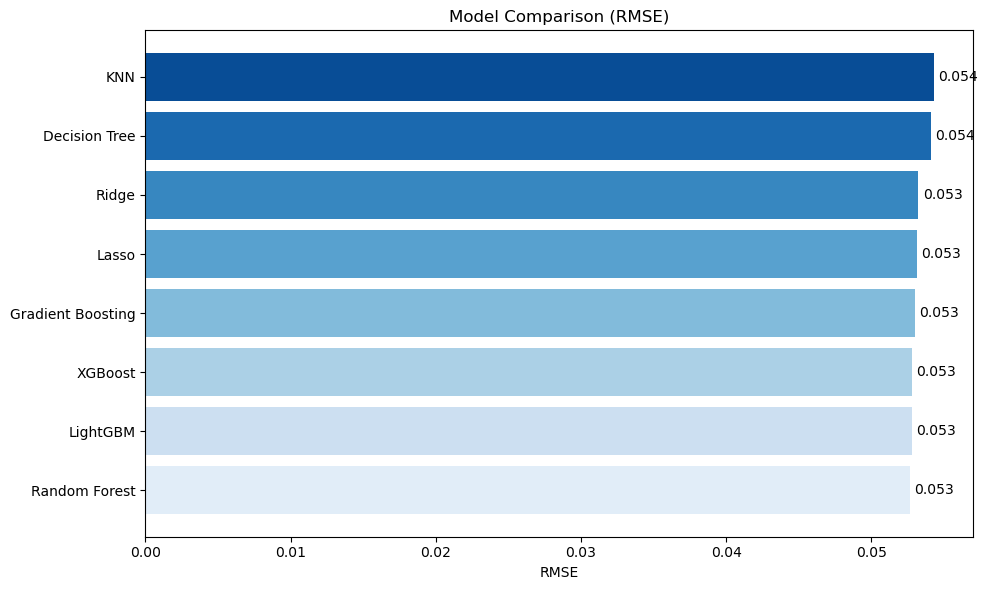

In [11]:
# Bar chart: R2
pd.Series({k: v["avg_r2"] for k, v in results_summary.items()}).sort_values().plot(
    kind='barh', figsize=(10, 6), title='Average R2 by Model')
plt.xlabel("R2 Score")
plt.tight_layout()
plt.show()

# Bar chart: RMSE
rmse_series = pd.Series({k: v["avg_rmse"] for k, v in results_summary.items()}).sort_values()
colors = sns.color_palette("Blues", len(rmse_series))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(rmse_series.index, rmse_series.values, color=colors)

# Annotate bars
for bar in bars:
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', va='center')

plt.xlabel("RMSE")
plt.title("Model Comparison (RMSE)")
plt.tight_layout()
plt.show()


In [12]:
# Get best LightGBM config
best_params_lgb = results_summary['LightGBM']['best_params']
final_lgb_model = lgb.LGBMRegressor(random_state=42, force_col_wise=True, **best_params_lgb)

# Use last fold for realistic out-of-time test
for train_idx, test_idx in tscv.split(X_model):
    pass

X_train_final = X_model.iloc[train_idx]
X_test_final = X_model.iloc[test_idx]
y_train_final = y.iloc[train_idx]
y_test_final = y.iloc[test_idx]

# Train and predict
final_lgb_model.fit(X_train_final, y_train_final)
y_pred_final = final_lgb_model.predict(X_test_final)


[LightGBM] [Info] Total Bins 2601
[LightGBM] [Info] Number of data points in the train set: 3695, number of used features: 40
[LightGBM] [Info] Start training from score 0.036316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [13]:
# Create investment simulation dataframe
Portfolio_return = pd.DataFrame({
    'Actual': y_test_final.values,
    'Prediction': y_pred_final,
    'Offer_Date': X_dates.iloc[test_idx]['Offer_Date'].values,
    'Issue_Date': X_dates.iloc[test_idx]['Issue_Date'].values,
    'Offer_Price': X_full.iloc[test_idx]['Offer_Price_USD'].values,
    'Shares_Offered_All_Mkts': X_full.iloc[test_idx]['Shares_Offered_All_Mkts'].values,
    'Shares_Offered_This_Mkt_PCT': X_full.iloc[test_idx]['Shares_Offered_This_Mkt_PCT'].values
})

# Calculate investment size assuming 10% participation
Portfolio_return['Shares_Offered_This_Mkt'] = Portfolio_return['Shares_Offered_All_Mkts'] * Portfolio_return['Shares_Offered_This_Mkt_PCT']
Portfolio_return['Max_Investment'] = Portfolio_return['Shares_Offered_This_Mkt'] * Portfolio_return['Offer_Price'] * 0.1

# Calculate holding period
Portfolio_return['Holding_Days'] = (
    pd.to_datetime(Portfolio_return['Issue_Date']) - pd.to_datetime(Portfolio_return['Offer_Date'])
).dt.days + 1


In [14]:
# Compute actual and expected daily returns
Portfolio_return['Daily_Return'] = Portfolio_return['Actual'] / Portfolio_return['Holding_Days']

# Create a copy to avoid changing the original data
portfolio = Portfolio_return.copy()

# Calculate expected and actual daily return
portfolio['Expected_Daily_Return'] = portfolio['Prediction'] / portfolio['Holding_Days']
portfolio['Actual_Daily_Return'] = portfolio['Actual'] / portfolio['Holding_Days']

# Sort by Offer Date and expected return to prioritize high-return predictions
portfolio_sorted = portfolio.sort_values(['Offer_Date', 'Expected_Daily_Return'], ascending=[True, False])

# Flag potential trades based on a threshold for expected return
threshold = 0.045
portfolio_sorted['Trade_Flag'] = portfolio_sorted['Expected_Daily_Return'] > threshold


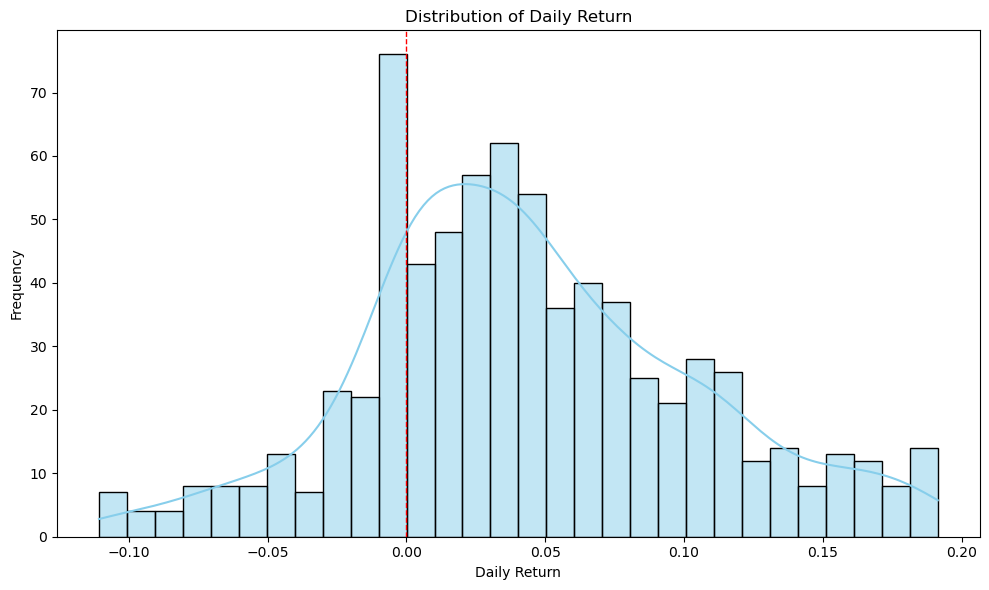

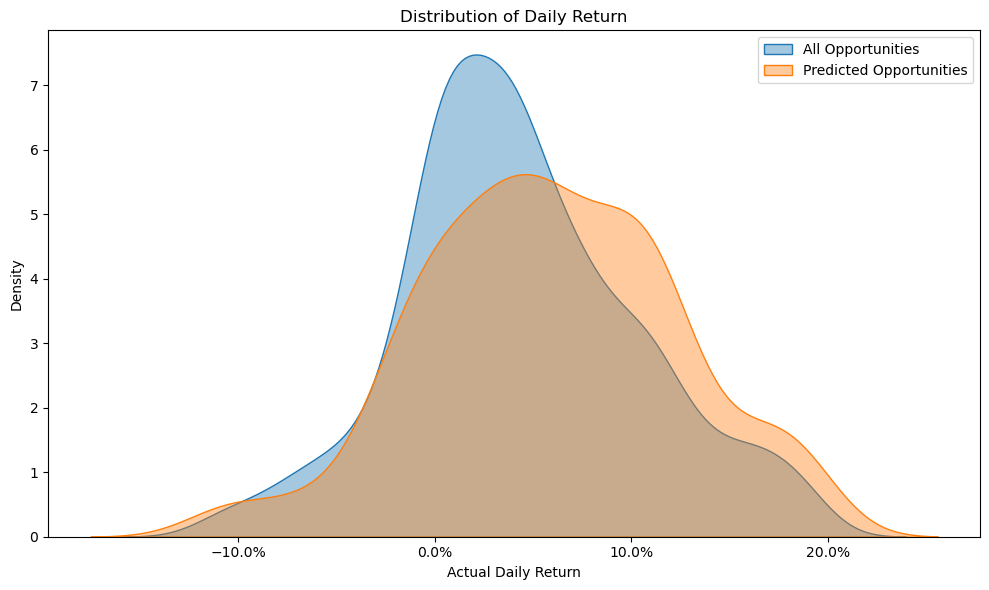

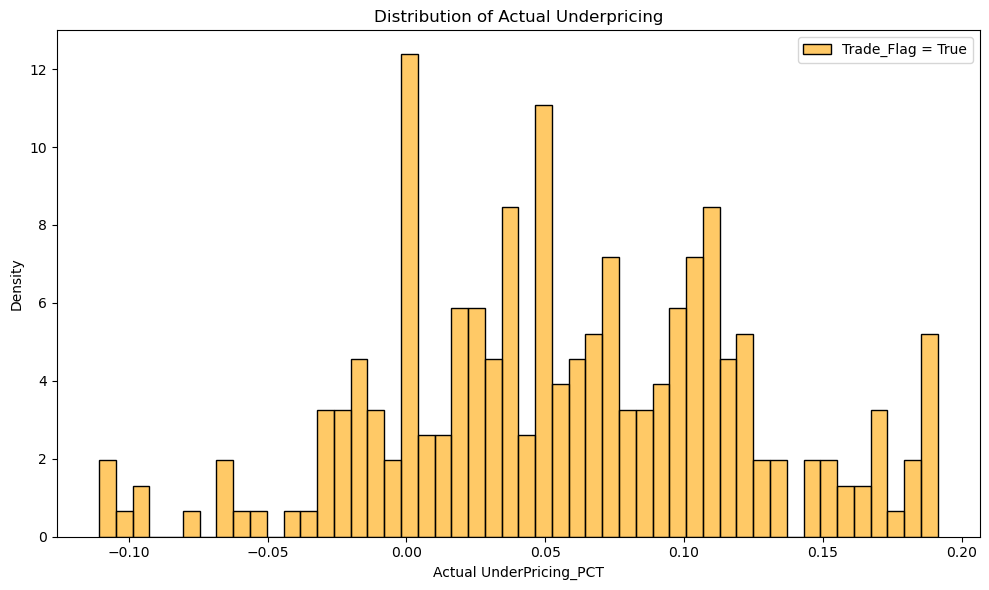

In [15]:
# Plot histogram of daily returns (all data)
plt.figure(figsize=(10, 6))
sns.histplot(data=Portfolio_return, x="Daily_Return", bins=30, kde=True, color="skyblue")
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title("Distribution of Daily Return")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# KDE plot: All vs. predicted trades
plt.figure(figsize=(10, 6))
sns.kdeplot(portfolio_sorted['Daily_Return'], label='All Opportunities', fill=True, alpha=0.4)
sns.kdeplot(portfolio_sorted[portfolio_sorted['Trade_Flag']]['Daily_Return'], 
            label='Predicted Opportunities', fill=True, alpha=0.4)
plt.title('Distribution of Daily Return')
plt.xlabel('Actual Daily Return')
plt.ylabel('Density')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

# Histogram of actual return for predicted trades only
plt.figure(figsize=(10, 6))
sns.histplot(data=portfolio_sorted[portfolio_sorted['Trade_Flag']], 
             x='Actual_Daily_Return', label='Trade_Flag = True', 
             color='orange', stat='density', bins=50, alpha=0.6)
plt.title('Distribution of Actual Underpricing')
plt.xlabel('Actual UnderPricing_PCT')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Count how many trades passed the threshold
No_transac = portfolio_sorted[portfolio_sorted['Trade_Flag'] == True].shape[0]
print(f"No of transaction: {No_transac} ")

# Initialize capital tracking
initial_capital = 1_000_000
capital = initial_capital
transaction_cost_pct = 0.05    # e.g. 5% per trade
max_pct_per_trade   = 0.1      # 10% of current capital
capital_timeline = []  # track portfolio value over time
active_trades = []     # list of current investments

# Ensure dates are datetime
portfolio_sorted['Offer_Date'] = pd.to_datetime(portfolio_sorted['Offer_Date'])
portfolio_sorted['Issue_Date'] = pd.to_datetime(portfolio_sorted['Issue_Date'])

# Simulate each day between first and last trade
all_dates = pd.date_range(start=portfolio_sorted['Offer_Date'].min(), 
                          end=portfolio_sorted['Issue_Date'].max())

for current_date in all_dates:
    # Remove matured trades from active list
    active_trades = [t for t in active_trades if t['Issue_Date'] > current_date]
    locked_capital = sum(t['Investment'] for t in active_trades)
    available_capital = capital - locked_capital

    # New trades triggered today
    today_trades = portfolio_sorted[(portfolio_sorted['Offer_Date'] == current_date) & 
                                    (portfolio_sorted['Trade_Flag'])]

    # Allocate capital to today's trades
    total_daily = 0
    for _, row in today_trades.iterrows():
        cap_limit     = capital * max_pct_per_trade
        invest_amount = min(row['Max_Investment'], available_capital, cap_limit)
        if invest_amount <= 0:
            continue

        gain = invest_amount * row['Daily_Return'] * row['Holding_Days']
        transaction_cost = invest_amount * transaction_cost_pct
        active_trades.append({'Issue_Date': row['Issue_Date'], 'Investment': invest_amount, 'Gain': gain, 'transaction_cost': transaction_cost})
        available_capital -= invest_amount
        total_daily += invest_amount

    # Add gains from matured trades
    for t in [t for t in active_trades if t['Issue_Date'] == current_date]:
        capital += t['Gain']
        capital -= t['transaction_cost']

    capital_timeline.append({'Date': current_date, 'Capital': capital, "Capital_used":total_daily})

# Store portfolio value timeline
capital_df = pd.DataFrame(capital_timeline)


No of transaction: 254 


In [17]:
capital_df['PCT_Capital_used'] = capital_df['Capital_used']/capital_df['Capital']

In [18]:
capital_df['PCT_Capital_used'].mean()

0.026083167351762315

In [19]:
# Sort by date and calculate daily return
capital_df = capital_df.sort_values(by='Date').reset_index(drop=True)
capital_df['Daily_Return'] = capital_df['Capital'].pct_change()

# Extract start/end values
initial_capital = capital_df['Capital'].iloc[0]
final_capital = capital_df['Capital'].iloc[-1]
total_days = (capital_df['Date'].iloc[-1] - capital_df['Date'].iloc[0]).days

# Annualization factor
annual_factor = 252

# Return metrics
total_return = (final_capital - initial_capital) / initial_capital
cagr = (final_capital / initial_capital) ** (annual_factor / total_days) - 1
annual_volatility = capital_df['Daily_Return'].std() * np.sqrt(annual_factor)
sharpe_ratio = cagr / annual_volatility if annual_volatility > 0 else np.nan

# Max drawdown
rolling_max = capital_df['Capital'].cummax()
drawdown = (capital_df['Capital'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# IRR approximation
capital_changes = capital_df['Capital'].diff().fillna(0)
irr = numpy_financial.irr(capital_changes.values)

# Store performance summary
performance_summary = {
    'Total Return (%)': total_return * 100,
    'CAGR (%)': cagr * 100,
    'Annualized Volatility (%)': annual_volatility * 100,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown (%)': max_drawdown * 100
}

# Display
print(performance_summary)


{'Total Return (%)': 24.188066909513527, 'CAGR (%)': 5.8076804814311656, 'Annualized Volatility (%)': 5.718883737845088, 'Sharpe Ratio': 1.0155269363142425, 'Max Drawdown (%)': -7.1521973379885235}


In [20]:
# Set your Alpha Vantage API key and fetch S&P 500 (SPY ETF) daily data
API_KEY = "3H84BAQGPVLU9G02"
ts = TimeSeries(key=API_KEY, output_format="pandas")
sp500_data, meta_data = ts.get_daily(symbol="SPY", outputsize="full")

# Align SP500 data with your strategy period
start_date = pd.to_datetime(capital_df['Date'].values[0])
end_date = pd.to_datetime(capital_df['Date'].values[-1])

# Filter SP500 data for the same time window
sp500_data.index = pd.to_datetime(sp500_data.index)
sp500_data = sp500_data[(sp500_data.index >= start_date) & (sp500_data.index <= end_date)]
sp500_data = sp500_data[['4. close']].reset_index().sort_values(by='date')

# Calculate SP500 daily return
sp500_data['SP500_Return'] = sp500_data['4. close'].pct_change()


In [21]:
# Merge your portfolio with SP500 returns
alpha = sp500_data.merge(capital_df, how='left', left_on='date', right_on='Date')
alpha['Capital_Return'] = alpha['Capital'].pct_change()

# Keep only relevant columns and drop the first NaN row
alpha = alpha[['date', 'SP500_Return', 'Capital_Return']].dropna()

# Regress Capital_Return on SP500_Return to get Alpha and Beta
X = alpha[['SP500_Return']]   # Market returns
y = alpha['Capital_Return']   # Strategy returns

model = LinearRegression()
model.fit(X, y)

alpha_val = model.intercept_
beta_val = model.coef_[0]

print(f"Alpha: {alpha_val:.5f} | Beta: {beta_val:.3f}")

# Add Alpha to performance summary
performance_summary['Alpha'] = alpha_val


Alpha: 0.00033 | Beta: 0.021


In [22]:
sp500_data

,date,4. close,SP500_Return
668,2021-04-28,417.40,NaN
667,2021-04-29,420.06,0.006373
666,2021-04-30,417.30,-0.006570
665,2021-05-03,418.20,0.002157
664,2021-05-04,415.62,-0.006169
...,...,...,...
4,2023-12-15,469.33,-0.005678
3,2023-12-18,471.97,0.005625
2,2023-12-19,474.84,0.006081
1,2023-12-20,468.26,-0.013857


In [23]:
capital_df

,Date,Capital,Capital_used,PCT_Capital_used,Daily_Return
0,2021-04-28,1.000000e+06,0.000000,0.000000,NaN
1,2021-04-29,9.998014e+05,200000.000000,0.200040,-0.000199
2,2021-04-30,9.998014e+05,0.000000,0.000000,0.000000
3,2021-05-01,9.998014e+05,0.000000,0.000000,0.000000
4,2021-05-02,9.998014e+05,0.000000,0.000000,0.000000
...,...,...,...,...,...
963,2023-12-17,1.251536e+06,0.000000,0.000000,0.000000
964,2023-12-18,1.241881e+06,125153.618582,0.100777,-0.007715
965,2023-12-19,1.241881e+06,0.000000,0.000000,0.000000
966,2023-12-20,1.241881e+06,0.000000,0.000000,0.000000


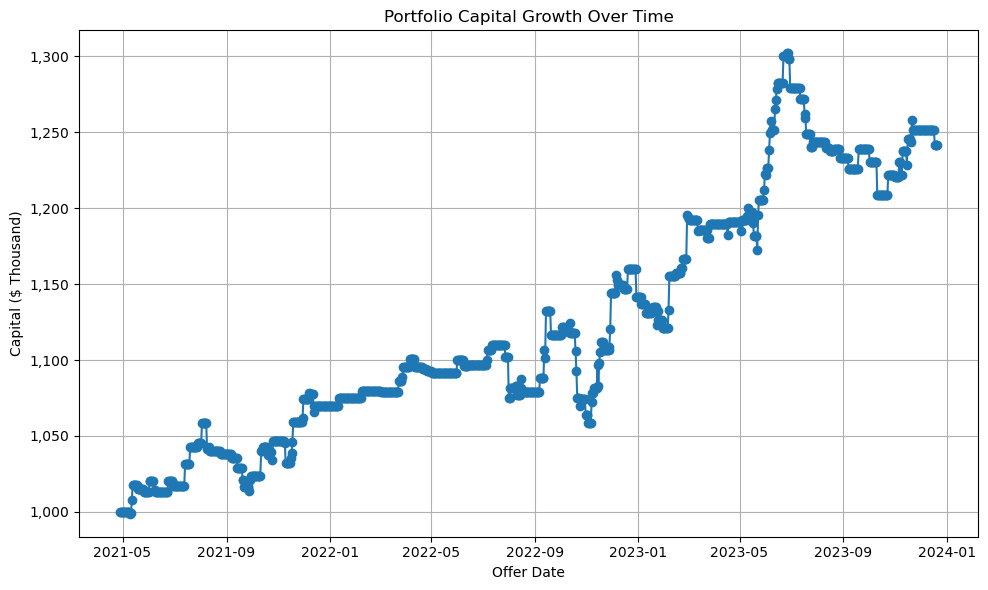

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(capital_df['Date'], capital_df['Capital'] / 1_000, marker='o')

# Format y-axis ticks with commas
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.set_title('Portfolio Capital Growth Over Time')
ax.set_xlabel('Offer Date')
ax.set_ylabel('Capital ($ Thousand)')
ax.grid(True)
plt.tight_layout()
plt.show()

In [25]:
sp500_data

,date,4. close,SP500_Return
668,2021-04-28,417.40,NaN
667,2021-04-29,420.06,0.006373
666,2021-04-30,417.30,-0.006570
665,2021-05-03,418.20,0.002157
664,2021-05-04,415.62,-0.006169
...,...,...,...
4,2023-12-15,469.33,-0.005678
3,2023-12-18,471.97,0.005625
2,2023-12-19,474.84,0.006081
1,2023-12-20,468.26,-0.013857


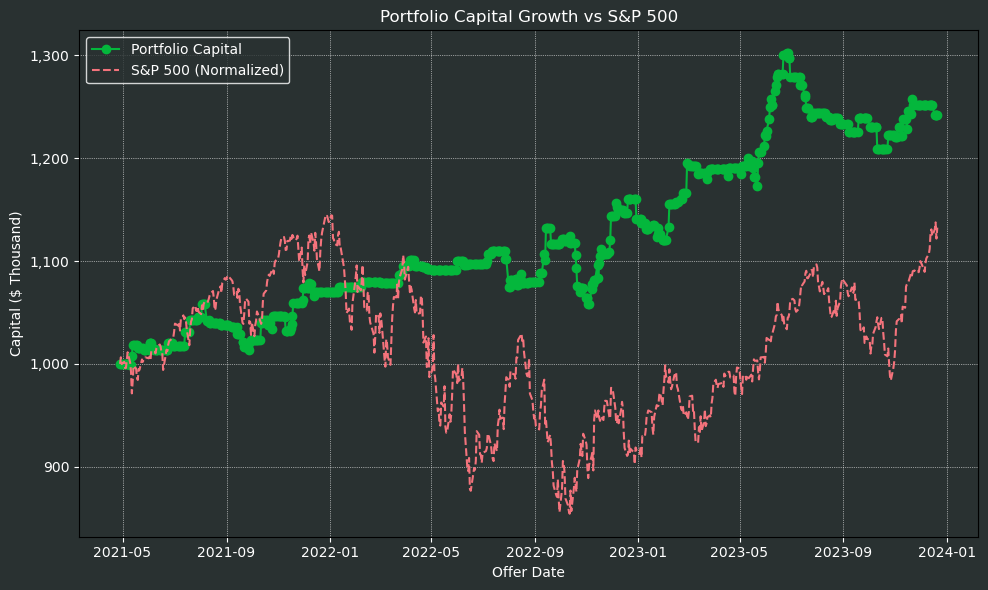

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure datetime format
capital_df['Date'] = pd.to_datetime(capital_df['Date'])
sp500_data['Date'] = pd.to_datetime(sp500_data['date'])

# Rename and merge
#sp500_data = sp500_data.rename(columns={'date': 'Date'})
merged_df = pd.merge(capital_df, sp500_data, on='Date', how='inner')

# Normalize S&P 500 for comparison
initial_sp500 = merged_df['4. close'].iloc[0]
merged_df['SP500_Normalized'] = merged_df['4. close'] / initial_sp500 * (capital_df['Capital'].iloc[0] / 1_000)

# Set the dark theme
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#293131')
ax.set_facecolor('#293131')

# Plotting
ax.plot(merged_df['Date'], merged_df['Capital'] / 1_000, label='Portfolio Capital', color='#04B73C', marker='o')
ax.plot(merged_df['Date'], merged_df['SP500_Normalized'], label='S&P 500 (Normalized)', color='#F4737C', linestyle='--')

# Styling
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.set_title('Portfolio Capital Growth vs S&P 500', color='white')
ax.set_xlabel('Offer Date', color='white')
ax.set_ylabel('Capital ($ Thousand)', color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.grid(True, color='white', linestyle=':', linewidth=0.5)
ax.legend(facecolor='#293131', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()



In [27]:
# Track running max and compute drawdown
capital_df['Running_Max'] = capital_df['Capital'].cummax()
capital_df['Drawdown'] = capital_df['Capital'] / capital_df['Running_Max'] - 1
max_drawdown = capital_df['Drawdown'].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")


Maximum Drawdown: -7.15%


In [28]:
# Total return over full period
total_return = capital_df['Capital'].iloc[-1] / capital_df['Capital'].iloc[0] - 1

# Estimate number of years
n_years = (capital_df['Date'].iloc[-1] - capital_df['Date'].iloc[0]).days / 365.25

# Annualized return (CAGR)
annual_return = (1 + total_return) ** (1 / n_years) - 1

# Annualized volatility from daily returns
daily_returns = capital_df['Capital'].pct_change().dropna()
annual_volatility = daily_returns.std() * np.sqrt(252)

# Compute excess return (assuming 2% risk-free rate)
annual_rf = 0.02
excess_return = annual_return - annual_rf

# Annualized Sharpe Ratio
sharpe_annual = excess_return / annual_volatility

print(f"Annualised Sharpe Ratio (using annual return): {sharpe_annual:.2f}")


Annualised Sharpe Ratio (using annual return): 1.14


In [29]:
# Count how many trades passed the threshold
No_transac = portfolio_sorted[portfolio_sorted['Trade_Flag'] == True].shape[0]
print(f"No of transaction: {No_transac} ")

# Initialize capital tracking
initial_capital = 1_000_000
capital = initial_capital
transaction_cost_pct = 0.05    # e.g. 5% per trade
max_pct_per_trade   = 0.1      # 10% of current capital
capital_timeline = []  # track portfolio value over time
active_trades = []     # list of current investments

# Ensure dates are datetime
portfolio_sorted['Offer_Date'] = pd.to_datetime(portfolio_sorted['Offer_Date'])
portfolio_sorted['Issue_Date'] = pd.to_datetime(portfolio_sorted['Issue_Date'])

# Simulate each day between first and last trade
all_dates = pd.date_range(start=portfolio_sorted['Offer_Date'].min(), 
                          end=portfolio_sorted['Issue_Date'].max())

for current_date in all_dates:
    # Remove matured trades from active list
    active_trades = [t for t in active_trades if t['Issue_Date'] > current_date]
    locked_capital = sum(t['Investment'] for t in active_trades)
    available_capital = capital - locked_capital

    # New trades triggered today
    today_trades = portfolio_sorted[(portfolio_sorted['Offer_Date'] == current_date) & 
                                    (portfolio_sorted['Trade_Flag'])]

    # Allocate capital to today's trades
    for _, row in today_trades.iterrows():
        cap_limit     = capital * max_pct_per_trade
        invest_amount = min(row['Max_Investment'], available_capital, cap_limit)
        if invest_amount <= 0:
            continue

        gain = invest_amount * row['Daily_Return'] * row['Holding_Days']
        transaction_cost = invest_amount * transaction_cost_pct
        active_trades.append({'Issue_Date': row['Issue_Date'], 'Investment': invest_amount, 'Gain': gain, 'transaction_cost': transaction_cost})
        available_capital -= invest_amount

    # Add gains from matured trades
    for t in [t for t in active_trades if t['Issue_Date'] == current_date]:
        capital += t['Gain']
        capital -= t['transaction_cost']

    capital_timeline.append({'Date': current_date, 'Capital': capital})

# Store portfolio value timeline
capital_df = pd.DataFrame(capital_timeline)


No of transaction: 254 


In [30]:
def simulate_strategy(portfolio, threshold, cost_rate, initial_capital=1_000_000, risk_free_rate=0.03, max_pct_per_trade=0.1):
    portfolio = portfolio.copy()
    portfolio['Expected_Daily_Return'] = portfolio['Prediction'] / portfolio['Holding_Days']
    portfolio_sorted = portfolio.sort_values(['Offer_Date', 'Expected_Daily_Return'], ascending=[True, False])
    portfolio_sorted['Trade_Flag'] = portfolio_sorted['Expected_Daily_Return'] > threshold

    portfolio_sorted['Offer_Date'] = pd.to_datetime(portfolio_sorted['Offer_Date'])
    portfolio_sorted['Issue_Date'] = pd.to_datetime(portfolio_sorted['Issue_Date'])

    all_dates = pd.date_range(start=portfolio_sorted['Offer_Date'].min(),
                              end=portfolio_sorted['Issue_Date'].max())

    capital = initial_capital
    active_trades = []
    capital_timeline = []

    for current_date in all_dates:
        # 1) Settle matured trades
        matured = [t for t in active_trades if t['Issue_Date'] == current_date]
        for t in matured:
            capital += t['Gain']               # add back principal + gross gain
            capital -= t['transaction_cost']   # subtract exit fee
        # 2) Remove them from the active list
        active_trades = [t for t in active_trades if t['Issue_Date'] > current_date]

        # 3) Compute available capital
        locked_capital    = sum(t['Investment'] for t in active_trades)
        available_capital = capital - locked_capital

        # 4) Trigger today’s trades
        today_trades = portfolio_sorted[
            (portfolio_sorted['Offer_Date'] == current_date) &
            (portfolio_sorted['Trade_Flag'])
        ]
        for _, row in today_trades.iterrows():
            cap_limit      = capital * max_pct_per_trade
            invest_amount  = min(row['Max_Investment'], available_capital, cap_limit)
            if invest_amount <= 0:
                continue

            gross_gain       = invest_amount * row['Daily_Return'] * row['Holding_Days']
            exit_fee         = invest_amount * cost_rate

            # store both gross gain and exit fee
            active_trades.append({
                'Issue_Date'      : row['Issue_Date'],
                'Investment'      : invest_amount,
                'Gain'            : gross_gain,
                'transaction_cost': exit_fee
            })
            available_capital -= invest_amount

        # Add gains from matured trades
        for t in [t for t in active_trades if t['Issue_Date'] == current_date]:
            capital += t['Gain']
            capital -= t['transaction_cost']



        # 5) Snapshot your capital
        capital_timeline.append({'Date': current_date, 'Capital': capital})

    # Create DataFrame for capital over time
    capital_df = pd.DataFrame(capital_timeline)
    capital_df['Daily_Return'] = capital_df['Capital'].pct_change().fillna(0)

    # Final performance metrics
    final_value = capital_df['Capital'].iloc[-1]
    total_return = (final_value - initial_capital) / initial_capital
    num_days = len(capital_df)
    cagr = (final_value / initial_capital) ** (365 / num_days) - 1

    # Sharpe Ratio
    avg_daily_return = capital_df['Daily_Return'].mean()
    std_daily_return = capital_df['Daily_Return'].std()
    sharpe = ((1 + avg_daily_return) ** 252 - 1 - risk_free_rate) / (std_daily_return * np.sqrt(252)) if std_daily_return > 0 else np.nan

    # Alpha
    # Merge with SP500 returns
    merged = sp500_data.merge(capital_df, how='left', left_on='date', right_on='Date')
    merged['Capital_Return'] = merged['Capital'].pct_change()
    merged = merged[['date', 'SP500_Return', 'Capital_Return']].dropna()

    # Regression for alpha & beta
    X = merged[['SP500_Return']]
    y = merged['Capital_Return']
    lr = LinearRegression().fit(X, y)
    alpha = lr.intercept_
    beta = lr.coef_[0]

    return final_value, total_return, cagr, sharpe, alpha, beta

In [31]:

from itertools import product

# Your grids
thresholds = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06]
transaction_costs = [0.02, 0.03, 0.04,0.05, 0.06]  # 2–6%
max_pct_per_trade = 0.05                            # 5% AUM cap

# Initialize an empty list to store results
results = []

# Loop through each threshold level
for threshold in thresholds:
    
    # Loop through each transaction cost
    for cost in transaction_costs:
        
        # Simulate strategy performance with the given threshold and cost
        final_cap, total_ret, cagr, sharpe, alpha, beta = simulate_strategy(
            Portfolio_return, threshold, cost
        )
        
        # Append the metrics to results list as a dictionary
        results.append({
            'Threshold': threshold,
            'Transaction_Cost': cost,
            'Final_Capital': final_cap,
            'Total_Return': total_ret,
            'CAGR': cagr,
            'Sharpe_Ratio': sharpe,
            'Alpha': alpha,
            'Beta': beta
        })

# Convert the results list into a structured DataFrame
sensitivity_df = pd.DataFrame(results)



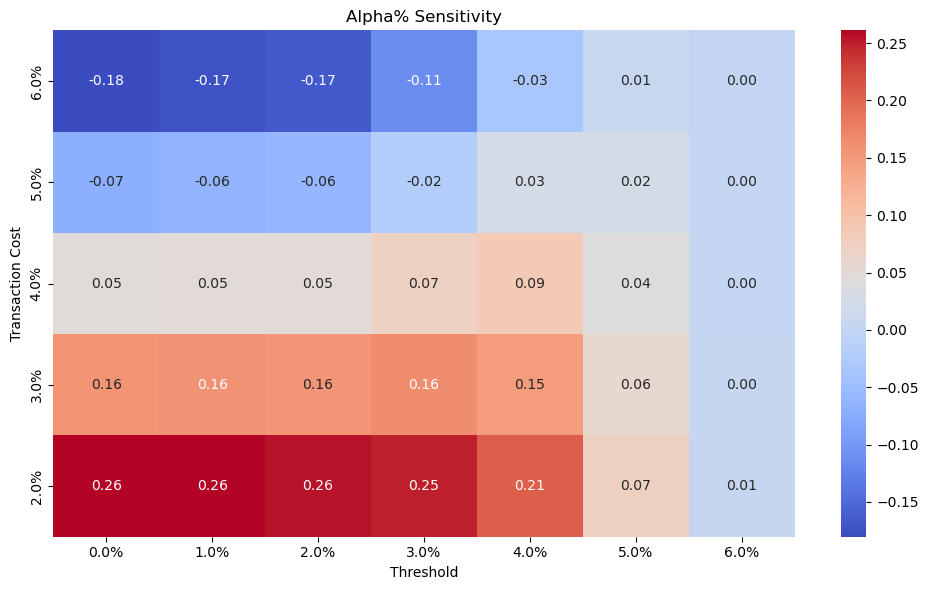

In [32]:

# Step 1: Pivot the DataFrame to shape it for heatmap
# Rows = Transaction Costs (Y-axis), Columns = Thresholds (X-axis), Values = Alpha (in %)
alpha_pivot = sensitivity_df.pivot(index='Transaction_Cost', columns='Threshold', values='Alpha')*100

# Step 2: Sort transaction cost values in descending order (better readability)
alpha_pivot = alpha_pivot.sort_index(ascending=False)

# Step 3: Format row/column labels as percentages for readability
alpha_pivot.index = [f"{x * 100:.1f}%" for x in alpha_pivot.index]
alpha_pivot.columns = [f"{x * 100:.1f}%" for x in alpha_pivot.columns]

# Step 4: Plot the heatmap
plt.figure(figsize=(10, 6))  # Optional: Set figure size
sns.heatmap(alpha_pivot, annot=True, fmt=".2f", cmap="coolwarm")

# Step 5: Add title and axis labels
plt.title("Alpha% Sensitivity")
plt.xlabel("Threshold")
plt.ylabel("Transaction Cost")

# Step 6: Ensure layout fits
plt.tight_layout()
plt.show()


C:\Users\Analog iT\AppData\Local\Temp\ipykernel_17988\1628039358.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


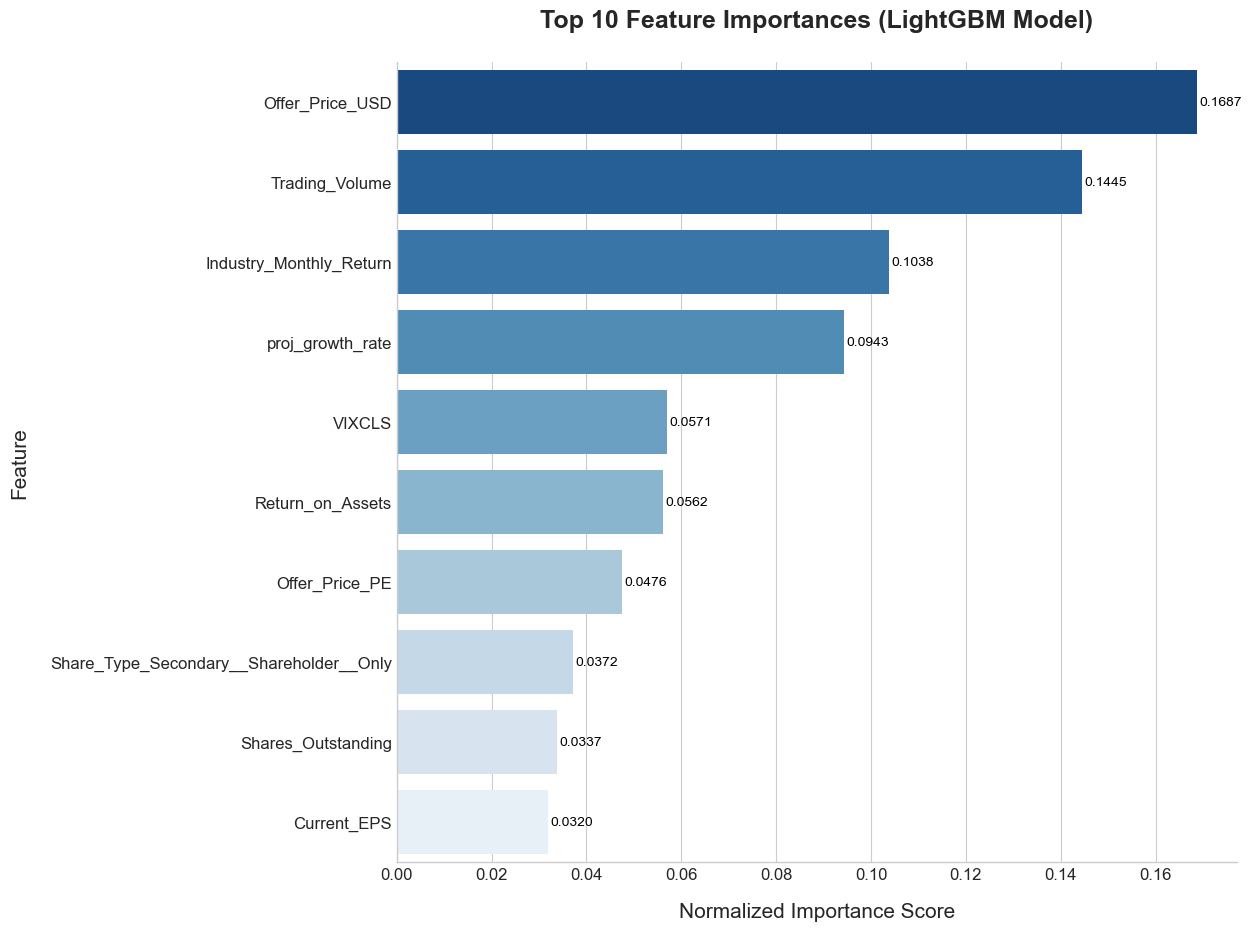

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assuming your previous code has been run ---
# final_lgb_model = ... (your trained LightGBM model)
# X_model = ... (your DataFrame of features used in the model)

# importances = final_lgb_model.feature_importances_
# features = X_model.columns

# feature_importance_df = pd.DataFrame({
# 'Feature': features,
# 'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# feature_importance_df['Normalized_Importance'] = feature_importance_df['Importance'] / feature_importance_df['Importance'].sum()

# --- For demonstration, let's recreate a sample feature_importance_df ---
# (Replace this with your actual feature_importance_df)
feature_data = {
    'Feature': [
        "Offer_Price_USD", "Trading_Volume", "Industry_Monthly_Return", "proj_growth_rate",
        "VIXCLS", "Return_on_Assets", "Offer_Price_PE", "Share_Type_Secondary__Shareholder__Only",
        "Shares_Outstanding", "Current_EPS", "Net_Profit_Margin", "HML",
        "Real_per_capita_personal_income_4_PCT_change", "Last_day_T_Bill_1YR_Rate",
        "Real_GDP__millions_of_chained_2017_dollars__1_...", "Return_on_Equity",
        "VIX_pct_change", "Current_dollar_GDP__millions_of_current_dollar...",
        "tbill_30_return", "Population__midperiod__persons__1_QoQ_change",
        "Another_Feature_21", "Another_Feature_22" # Adding more to simulate a larger full set
    ],
    'Importance': [
        195, 167, 120, 109, 66, 65, 55, 43, 39, 37, 36, 35, 35, 25, 23, 23, 18, 18, 16, 16, 10, 5
    ]
}
# Ensure this DataFrame matches the structure of your 'feature_importance_df'
feature_importance_df_full = pd.DataFrame(feature_data)
feature_importance_df_full = feature_importance_df_full.sort_values(by='Importance', ascending=False)
feature_importance_df_full['Normalized_Importance'] = feature_importance_df_full['Importance'] / feature_importance_df_full['Importance'].sum()

# Now, get the top 20 for plotting, similar to your code
df_top20 = feature_importance_df_full.head(10).copy() # Use .copy() to avoid SettingWithCopyWarning if you modify it

# --- Enhanced Plotting Section ---

# Apply a professional and clean seaborn style
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14, 10)) # Increased figure size for better label visibility

# Create the horizontal bar plot using Seaborn
# We'll plot 'Normalized_Importance' for better comparability
# The features are already sorted by importance in df_top20
barplot = sns.barplot(
    x='Normalized_Importance',
    y='Feature',
    data=df_top20,
    palette='Blues_r' # Using a reversed blue color palette for a professional look (darker for more important)
    # You can also use a single color e.g., color='steelblue'
)

# --- Chart Customization for a Professional Look ---

# Set the title with increased font size and padding
plt.title("Top 10 Feature Importances (LightGBM Model)", fontsize=18, fontweight='bold', pad=25)

# Set axis labels with increased font size and padding
plt.xlabel("Normalized Importance Score", fontsize=15, labelpad=15)
plt.ylabel("Feature", fontsize=15, labelpad=15)

# Customize tick parameters for better readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) # Fontsize for feature names

# Add data labels to the end of each bar for precise values
for index, row in df_top20.iterrows():
    # Position the text slightly outside the bar end
    # Adjust the 'row['Normalized_Importance'] + 0.001' based on your data range for optimal spacing
    barplot.text(row['Normalized_Importance'] + 0.0005, # X-coordinate for the text
                 index, # Y-coordinate for the text (matches the bar index)
                 f"{row['Normalized_Importance']:.4f}", # Text to display (formatted to 4 decimal places)
                 color='black',
                 va='center', # Vertical alignment
                 fontsize=10)


# Improve layout to prevent labels from overlapping
# plt.tight_layout() might be too aggressive with seaborn sometimes.
# Adjusting margins or using specific bbox_inches='tight' for savefig is often better.
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1) # Adjust margins if feature names are long

# Remove top and right spines for a cleaner, modern aesthetic
sns.despine(left=False, bottom=False) # Keep left and bottom spines for clarity

# Show the plot
plt.show()

# To save the figure for your report:
# plt.savefig('professional_feature_importance.png', dpi=300, bbox_inches='tight')

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure datetime format
capital_df['Date'] = pd.to_datetime(capital_df['Date'])
sp500_data['date'] = pd.to_datetime(sp500_data['date'])

# Rename and merge
sp500_data = sp500_data.rename(columns={'date': 'Date'})
merged_df = pd.merge(capital_df, sp500_data, on='Date', how='inner')

# Normalize S&P 500 for comparison
initial_sp500 = merged_df['4. close'].iloc[0]
merged_df['SP500_Normalized'] = merged_df['4. close'] / initial_sp500 * (capital_df['Capital'].iloc[0] / 1_000)

# Set the dark theme
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#293131')
ax.set_facecolor('#293131')

# Plotting
ax.plot(merged_df['Date'], merged_df['Capital'] / 1_000, label='Portfolio Capital', color='#04B73C', marker='o')
ax.plot(merged_df['Date'], merged_df['SP500_Normalized'], label='S&P 500 (Normalized)', color='#F4737C', linestyle='--')

# Styling
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.set_title('Portfolio Capital Growth vs S&P 500', color='white')
ax.set_xlabel('Offer Date', color='white')
ax.set_ylabel('Capital ($ Thousand)', color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.grid(True, color='white', linestyle=':', linewidth=0.5)
ax.legend(facecolor='#293131', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()


ValueError: The column label 'Date' is not unique.

In [38]:
sp500_data

,Date,4. close,SP500_Return,Date
668,2021-04-28,417.40,NaN,2021-04-28
667,2021-04-29,420.06,0.006373,2021-04-29
666,2021-04-30,417.30,-0.006570,2021-04-30
665,2021-05-03,418.20,0.002157,2021-05-03
664,2021-05-04,415.62,-0.006169,2021-05-04
...,...,...,...,...
4,2023-12-15,469.33,-0.005678,2023-12-15
3,2023-12-18,471.97,0.005625,2023-12-18
2,2023-12-19,474.84,0.006081,2023-12-19
1,2023-12-20,468.26,-0.013857,2023-12-20


In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make sure both DataFrames have datetime format for dates
capital_df['Date'] = pd.to_datetime(capital_df['Date'])
#sp500_data['Date'] = pd.to_datetime(sp500_data['Date'])

# Normalize S&P 500 prices to the same scale as initial capital (1,000,000 base)
# or just plot both on different y-axes
#sp500_data = sp500_data.rename(columns={'date': 'Date'})
merged_df = pd.merge(capital_df, sp500_data, on='Date', how='inner')

# Option 1: Plot on the same y-axis by normalizing S&P 500
initial_sp500 = merged_df['4. close'].iloc[0]
merged_df['SP500_Normalized'] = merged_df['4. close'] / initial_sp500 * (capital_df['Capital'].iloc[0] / 1_000)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot capital
ax.plot(merged_df['Date'], merged_df['Capital'] / 1_000, label='Portfolio Capital', marker='o')

# Plot normalized S&P 500
ax.plot(merged_df['Date'], merged_df['SP500_Normalized'], label='S&P 500 (Normalized)', linestyle='--')

# Format y-axis
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.set_title('Portfolio Capital Growth vs S&P 500')
ax.set_xlabel('Offer Date')
ax.set_ylabel('Capital ($ Thousand)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


ValueError: The column label 'Date' is not unique.